In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from apyori import apriori as apr
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

In [2]:
import warnings 
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv(r"C:\Users\sanum\Desktop\assignment\assignments data\Association rules\my_movies.csv")

In [6]:
df

,V1,V2,V3,V4,V5,Sixth Sense,Gladiator,LOTR1,Harry Potter1,Patriot,LOTR2,Harry Potter2,LOTR,Braveheart,Green Mile
0,Sixth Sense,LOTR1,Harry Potter1,Green Mile,LOTR2,1,0,1,1,0,1,0,0,0,1
1,Gladiator,Patriot,Braveheart,NaN,NaN,0,1,0,0,1,0,0,0,1,0
2,LOTR1,LOTR2,NaN,NaN,NaN,0,0,1,0,0,1,0,0,0,0
3,Gladiator,Patriot,Sixth Sense,NaN,NaN,1,1,0,0,1,0,0,0,0,0
4,Gladiator,Patriot,Sixth Sense,NaN,NaN,1,1,0,0,1,0,0,0,0,0
5,Gladiator,Patriot,Sixth Sense,NaN,NaN,1,1,0,0,1,0,0,0,0,0
6,Harry Potter1,Harry Potter2,NaN,NaN,NaN,0,0,0,1,0,0,1,0,0,0
7,Gladiator,Patriot,NaN,NaN,NaN,0,1,0,0,1,0,0,0,0,0
8,Gladiator,Patriot,Sixth Sense,NaN,NaN,1,1,0,0,1,0,0,0,0,0
9,Sixth Sense,LOTR,Gladiator,Green Mile,NaN,1,1,0,0,0,0,0,1,0,1


In [7]:
df1=df.iloc[:,5:]
df1.head()

,Sixth Sense,Gladiator,LOTR1,Harry Potter1,Patriot,LOTR2,Harry Potter2,LOTR,Braveheart,Green Mile
0,1,0,1,1,0,1,0,0,0,1
1,0,1,0,0,1,0,0,0,1,0
2,0,0,1,0,0,1,0,0,0,0
3,1,1,0,0,1,0,0,0,0,0
4,1,1,0,0,1,0,0,0,0,0


In [9]:
df1.describe().T

,count,mean,std,min,25%,50%,75%,max
Sixth Sense,10.0,0.6,0.516398,0.0,0.00,1.0,1.0,1.0
Gladiator,10.0,0.7,0.483046,0.0,0.25,1.0,1.0,1.0
LOTR1,10.0,0.2,0.421637,0.0,0.00,0.0,0.0,1.0
Harry Potter1,10.0,0.2,0.421637,0.0,0.00,0.0,0.0,1.0
Patriot,10.0,0.6,0.516398,0.0,0.00,1.0,1.0,1.0
LOTR2,10.0,0.2,0.421637,0.0,0.00,0.0,0.0,1.0
Harry Potter2,10.0,0.1,0.316228,0.0,0.00,0.0,0.0,1.0
LOTR,10.0,0.1,0.316228,0.0,0.00,0.0,0.0,1.0
Braveheart,10.0,0.1,0.316228,0.0,0.00,0.0,0.0,1.0
Green Mile,10.0,0.2,0.421637,0.0,0.00,0.0,0.0,1.0


In [11]:
df1.isnull().sum()

Sixth Sense      0
Gladiator        0
LOTR1            0
Harry Potter1    0
Patriot          0
LOTR2            0
Harry Potter2    0
LOTR             0
Braveheart       0
Green Mile       0
dtype: int64

In [12]:
df1.dtypes

Sixth Sense      int64
Gladiator        int64
LOTR1            int64
Harry Potter1    int64
Patriot          int64
LOTR2            int64
Harry Potter2    int64
LOTR             int64
Braveheart       int64
Green Mile       int64
dtype: object

In [13]:
te=TransactionEncoder()

In [14]:
te_ary=te.fit(df1).transform(df1)

In [15]:
ap=pd.DataFrame(te_ary, columns=te.columns_)

<Axes: title={'center': 'Frequent Items'}>

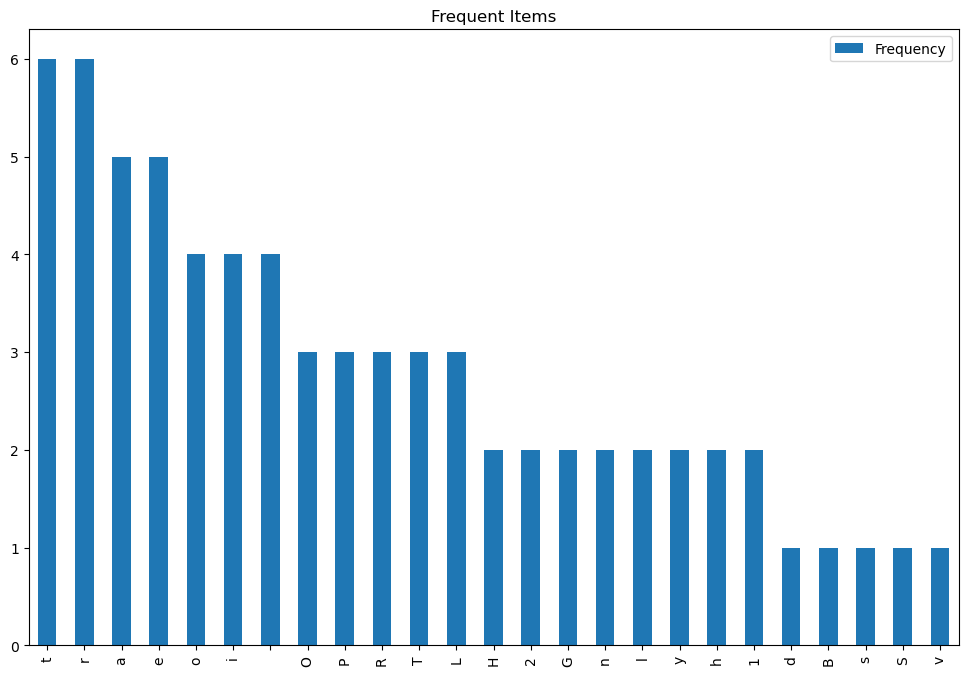

In [17]:
ap.sum().to_frame('Frequency').sort_values('Frequency', ascending =False)[:25].plot(kind='bar', figsize=(12,8), title=("Frequent Items"))

In [18]:
ap_0_5={}
ap_1={}
ap_5={}
ap_1_0={}

In [21]:
confidence = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
def gen_rules(df,confidence,support):
    ap = {}
    for i in confidence:
        ap_i =apriori(df1,support,True)
        rule= association_rules(ap_i,min_threshold=i)
        ap[i] = len(rule.antecedents)
    return pd.Series(ap).to_frame("Support: %s"%support)

In [24]:
confs=[]
for i in [0.005, 0.001, 0.003,0.007]:
    ap_i=gen_rules(ap, confidence=confidence, support =i)
    confs.append(ap_i)
all_conf=pd.concat(confs, axis=1)
all_conf

,Support: 0.005,Support: 0.001,Support: 0.003,Support: 0.007
0.1,250,250,250,250
0.2,220,220,220,220
0.3,217,217,217,217
0.4,216,216,216,216
0.5,216,216,216,216
0.6,134,134,134,134
0.7,129,129,129,129
0.8,128,128,128,128
0.9,125,125,125,125


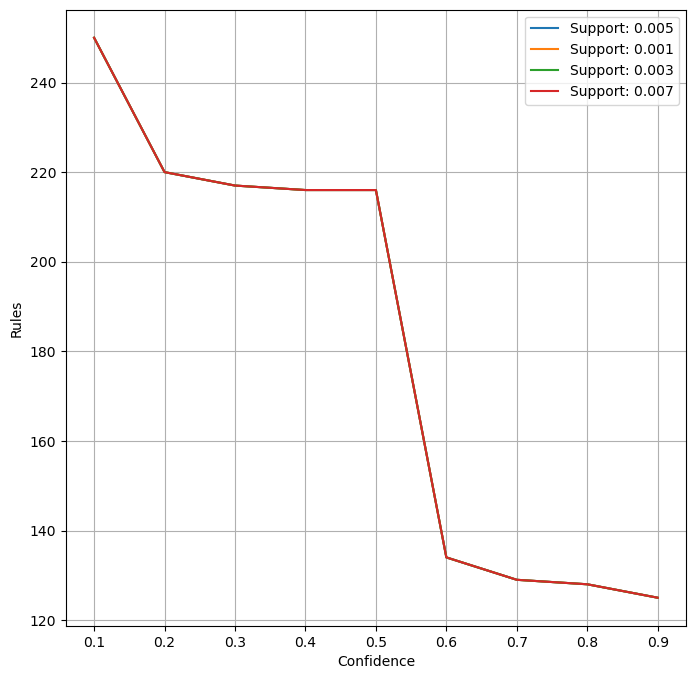

In [26]:
all_conf.plot(figsize=(8,8), grid=True)
plt.ylabel('Rules')
plt.xlabel('Confidence')
plt.show()

In [28]:
ap_final=apriori(ap,0.005,True)

In [29]:
rules_final=association_rules(ap_final, min_threshold=0.4, support_only=False)

In [32]:
rules_final[rules_final['confidence']>0.5]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
3,(H),( ),0.2,0.4,0.2,1.000000,2.500000,1.0,0.12,inf,0.750000,0.50,1.000000,0.750000
5,(M),( ),0.1,0.4,0.1,1.000000,2.500000,1.0,0.06,inf,0.666667,0.25,1.000000,0.625000
6,(P),( ),0.3,0.4,0.2,0.666667,1.666667,1.0,0.08,1.8,0.571429,0.40,0.444444,0.583333
8,(S),( ),0.1,0.4,0.1,1.000000,2.500000,1.0,0.06,inf,0.666667,0.25,1.000000,0.625000
11,(e),( ),0.5,0.4,0.4,0.800000,2.000000,1.0,0.20,3.0,1.000000,0.80,0.666667,0.900000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113719,"(2, a)","(y, , t, e, P, r, H, o)",0.1,0.2,0.1,1.000000,5.000000,1.0,0.08,inf,0.888889,0.50,1.000000,0.750000
113721,"(2, P)","(y, , t, e, a, r, H, o)",0.1,0.2,0.1,1.000000,5.000000,1.0,0.08,inf,0.888889,0.50,1.000000,0.750000
113723,"(r, 2)","(y, , t, e, a, P, H, o)",0.1,0.2,0.1,1.000000,5.000000,1.0,0.08,inf,0.888889,0.50,1.000000,0.750000
113724,"(H, 2)","(y, , t, e, a, P, r, o)",0.1,0.2,0.1,1.000000,5.000000,1.0,0.08,inf,0.888889,0.50,1.000000,0.750000


In [33]:
support= rules_final["support"]
confidence=rules_final["confidence"]
lift=rules_final['lift']

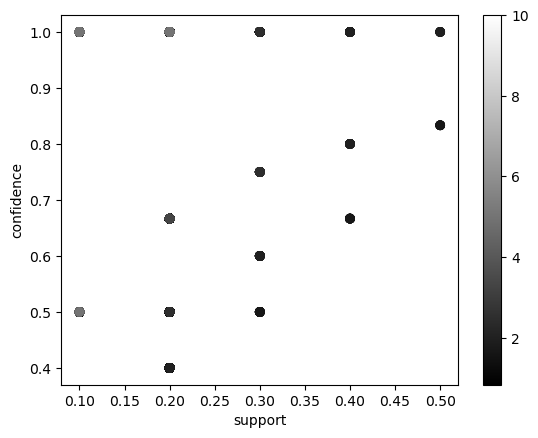

In [37]:
plt.scatter(support, confidence, c=lift, cmap='gray')
plt.colorbar()
plt.xlabel("support")
plt.ylabel("confidence")
plt.show()

positive correlation but not strong one